5. Взять для экспериментов размеры массивов от 100 до 5000 с шагом 100.
6. Сгенерировать (определить) три типа входных данных для каждого размера массива (лучший случай, средний случай, худший случай).
7. Для каждого алгоритма, каждого размера массива и каждого типа случая:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

8. На одном графике отобразить зависимости среднего времени работы (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
9. На одном графике отобразить зависимости количества операций (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
10. На одном графике отобразить зависимости глубины рекурсии (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий

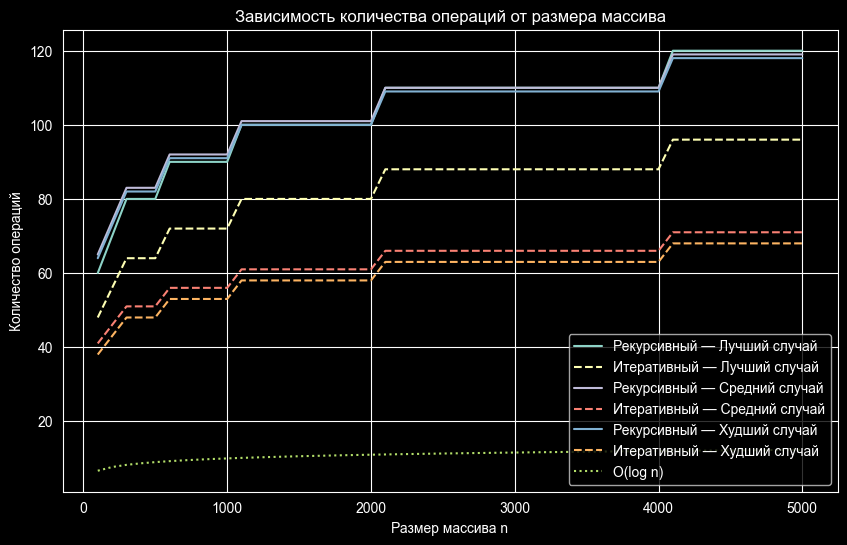

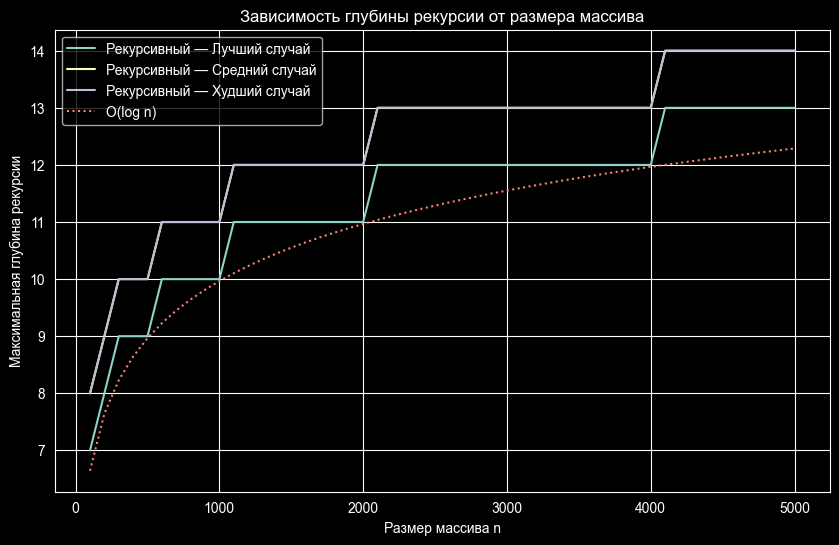

In [5]:
import time
import math
import matplotlib.pyplot as plt


sizes = list(range(100, 5001, 100))


def generate_array(n):
    return list(range(n))


# -----------------------------
# Левосторонний бинарный поиск — рекурсивный
# -----------------------------
def binary_search_left_rec(arr, target, l, r, depth=1):

    operations = 1
    if l >= r:                                                            # сравнение (l >= r) - 1 операция
        return l, operations, depth

    mid = (l + r) // 2                                                    # деление, сложение, присваивание - 3 операции
    operations += 3

    if arr[mid] < target:                                                 # сравнение, обращение к памяти (arr[mid]) - 2 операции
        result, child_ops, max_depth = binary_search_left_rec(            # присваивание, вызов функции, сложение - 3 операции
            arr, target, mid + 1, r, depth + 1
        )
        operations += 5
    else:
        result, child_ops, max_depth = binary_search_left_rec(           # присваивание, вызов функции - 2 операции
            arr, target, l, mid, depth + 1
        )
        operations += 4

    operations += 1
    return result, operations + child_ops, max_depth                     # сложение - 1 операция


# -----------------------------
# Левосторонний бинарный поиск — итеративный
# -----------------------------
def binary_search_left_iter(arr, target):
    l = 0                                                                # присваивание - 1 операция
    r = len(arr) - 1                                                     # присваивание, вычитание - 2 операции
    operations = 3

    while l < r:                                                        # сравнение,  деление, сложение, присваивание - 4 операции
        mid = (l + r) // 2
        operations += 4

        if arr[mid] < target:                                           # обращение к памяти, сравнение - 2 операции
            l = mid + 1                                                 # присваивание, сложение - 2 операции
            operations += 4
        else:
            r = mid                                                    # присваивание - 1 операция
            operations += 1

    return l, operations, 0


def measure_time(func, *args, repeats=10):
    total_time = 0

    for _ in range(repeats):
        start = time.perf_counter_ns()
        func(*args)
        end = time.perf_counter_ns()
        total_time += end - start

    return total_time / repeats


def get_cases(arr):
    n = len(arr)

    best = arr[(n - 1) // 2]
    average = arr[n // 4]
    worst = -1

    return {
        "Лучший случай": best,
        "Средний случай": average,
        "Худший случай": worst
    }


results = []

for n in sizes:
    arr = generate_array(n)
    cases = get_cases(arr)

    for case_name, target in cases.items():
        avg_time_rec = measure_time(
            binary_search_left_rec,
            arr, target, 0, len(arr) - 1,
            repeats=10
        )

        _, ops_rec, depth_rec = binary_search_left_rec(
            arr, target, 0, len(arr) - 1
        )

        avg_time_iter = measure_time(
            binary_search_left_iter,
            arr, target,
            repeats=10
        )

        _, ops_iter, depth_iter = binary_search_left_iter(arr, target)

        results.append({
            "n": n,
            "case": case_name,

            "time_rec": avg_time_rec,
            "ops_rec": ops_rec,
            "depth_rec": depth_rec,

            "time_iter": avg_time_iter,
            "ops_iter": ops_iter,
            "depth_iter": depth_iter
        })


def get_values(case_name, key):
    return [row[key] for row in results if row["case"] == case_name]


theory_log = [math.log2(n) for n in sizes]

# -----------------------------
# График 2: количество операций
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "ops_rec"), label=f"Рекурсивный — {case}")
    plt.plot(sizes, get_values(case, "ops_iter"), linestyle="--", label=f"Итеративный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Количество операций")
plt.title("Зависимость количества операций от размера массива")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# График 3: максимальная глубина рекурсии
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "depth_rec"), label=f"Рекурсивный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Максимальная глубина рекурсии")
plt.title("Зависимость глубины рекурсии от размера массива")
plt.legend()
plt.grid(True)
plt.show()

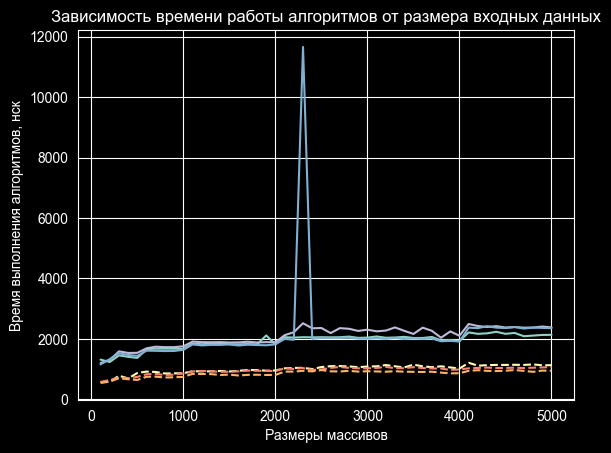

TypeError: get_values() missing 2 required positional arguments: 'case_name' and 'key'

<Figure size 1000x600 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

for case in ["Лучший случай", 'Средний случай', 'Худший случай']:
    plt.plot(sizes, get_values(case, 'time_rec'), label = f'Рекурсивный - {case}')
    plt.plot(sizes, get_values(case, 'time_iter'), linestyle = "--", label = f'Итеративный - {case}')

plt.xlabel("Размеры массивов")
plt.ylabel("Время выполнения алгоритмов, нск")
plt.title("Зависимость времени работы алгоритмов от размера входных данных")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(sizes, get_values())

In [ ]:
def measure_factorial_time(n, repeats=10): # repeats число повторов для одной сессии измерений
    times = []

    for _ in range(repeats):
        start = time.perf_counter_ns()
        result = factorial(n)
        end = time.perf_counter_ns()
        times.append(end - start)

    # убираем выбросы (минимальное и максимальное время) и усредняем
    if repeats > 2:
        times.sort()
        times = times[1:-1]

    avg_time = sum(times) / len(times)
    return avg_time, result

times_ns = [] # тут будет время работы
init_n = list(range(100, 1001, 50)) # тут будут исходные размеры входных данных

for n in init_n:
    time_ns, _ = measure_factorial_time(n, repeats=10)
    times_ns.append(time_ns)

In [ ]:
for _ in range(repeats):
        start = time.perf_counter_ns()
        result = factorial(n)
        end = time.perf_counter_ns()
        times.append(end - start)

    # убираем выбросы (минимальное и максимальное время) и усредняем
    if repeats > 2:
        times.sort()
        times = times[1:-1]

    avg_time = sum(times) / len(times)
    return avg_time, result

times_ns = [] # тут будет время работы
init_n = list(range(100, 1001, 50)) # тут будут исходные размеры входных данных

for n in init_n:
    time_ns, _ = measure_factorial_time(n, repeats=10)
    times_ns.append(time_ns)